In [1]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) return false;

<IPython.core.display.Javascript object>

In [2]:
import dataset, plots, features
import pandas as pd

sp500_components = dataset.SP500.load_historical()

## Dane cenowe

Do selekcji spółek do portfela z wykorzystaniem analizy technicznej w dłuższym terminie wystarczają wartości uzyskane pod koniec sesji każdego dnia (**End-of-Day, EOD**). Ponieważ dane muszą obejmować również spółki, które już nie istnieją, aby uniknąć błędów badawczych, darmowe źródła często okazują się niewystarczające. W praktyce można przyjąć dwa podejścia:

- pobranie danych cenowych z darmowych źródeł i uzupełnienie brakujących danych profesjonalnym dostawcą

- pobranie wszystkich danych bezpośrednio od profesjonalnego dostawcy.

W tym projekcie wybrane zostało pierwsze podejście, aby zwizualizować potencjalny wpływ brakujących lub niekompletnych danych na wyniki analizy.

### Dane cenowe z Yahoo Finance

Najpopularniejszą opcją pozyskania danych cenowych jest korzystanie z [**Yahoo Finance**](https://finance.yahoo.com/?guccounter=1), np. poprzez bibliotekę [**yfinance**](https://github.com/ranaroussi/yfinance) w Pythonie, która umożliwia pobranie danych historycznych spółek wraz z cenami skorygowanymi o splity i dywidendy.

#### Uzyskanie danych z pojedynczej spółki

Poniżej przykładowe użycie tej biblioteki w celu uzyskania historii cen akcji spółki Apple (AAPL). Dane cenowe zamknięcia (**Adj Close**) są już skorygowane o dywidendy.

In [3]:
apple = dataset.YahooFinance.get_ticker_data_incremental("AAPL", save_csv=True)

plots.summarize_df(apple)

Loading existing data for AAPL from AAPL.csv
No new trading days for AAPL since 2026-04-08
Saved data for AAPL to AAPL.csv
DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 11421 entries, 1980-12-12 05:00:00+00:00 to 2026-04-08 04:00:00+00:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          11421 non-null  float64
 1   High          11421 non-null  float64
 2   Low           11421 non-null  float64
 3   Close         11421 non-null  float64
 4   Adj Close     11421 non-null  float64
 5   Volume        11421 non-null  int64  
 6   Dividends     11421 non-null  float64
 7   Stock Splits  11421 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 803.0 KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,11421.00000000,11421.00000000,11421.00000000,11421.00000000,11421.00000000,11421.00000000,11421.00000000,11421.00000000
mean,30.21007633,30.53629797,29.90068925,30.23110961,29.27928352,308213751.72997111,0.00088115,0.00148849
std,60.71429343,61.36301223,60.11020346,60.76203281,60.22645548,333038271.35385078,0.01314850,0.08209958
min,0.04966500,0.04966500,0.04910700,0.04910700,0.03760944,0.00000000,0.00000000,0.00000000
25%,0.30524600,0.31138399,0.29910699,0.30524600,0.24742335,105260800.00000000,0.00000000,0.00000000
50%,0.60839301,0.62071401,0.59709799,0.60928601,0.49704421,197164800.00000000,0.00000000,0.00000000
75%,24.58071327,24.82500076,24.32999992,24.53000069,21.94142342,388292800.00000000,0.00000000,0.00000000
max,286.20001221,288.61999512,283.29998779,286.19000244,285.92245483,7421640800.00000000,0.26000000,7.00000000


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1980-12-12 05:00:00+00:00,0.12834799,0.12890600,0.12834799,0.12834799,0.09829751,469033600,0.00000000,0.00000000
1980-12-15 05:00:00+00:00,0.12221000,0.12221000,0.12165200,0.12165200,0.09316928,175884800,0.00000000,0.00000000
2026-04-07 04:00:00+00:00,256.16000366,256.20001221,245.69999695,253.50000000,253.50000000,61377300,0.00000000,0.00000000
2026-04-08 04:00:00+00:00,258.51000977,259.74990845,256.52999878,257.91000366,257.91000366,21750708,0.00000000,0.00000000


Poniższy fragment danych — dzień przed, w dniu oraz dzień po splicie akcji — pokazuje, że ceny w danych historycznych uwzględniają już split.

In [4]:
plots.YahooFinance.show_last_split(apple)

,Open,Adj Close,Dividends,Stock Splits
Date,,,,
2020-08-28 04:00:00+00:00,126.01249695,121.17153168,0.00000000,0.00000000
2020-08-31 04:00:00+00:00,127.58000183,125.28071594,0.00000000,4.00000000
2020-09-01 04:00:00+00:00,132.75999451,130.27098083,0.00000000,0.00000000


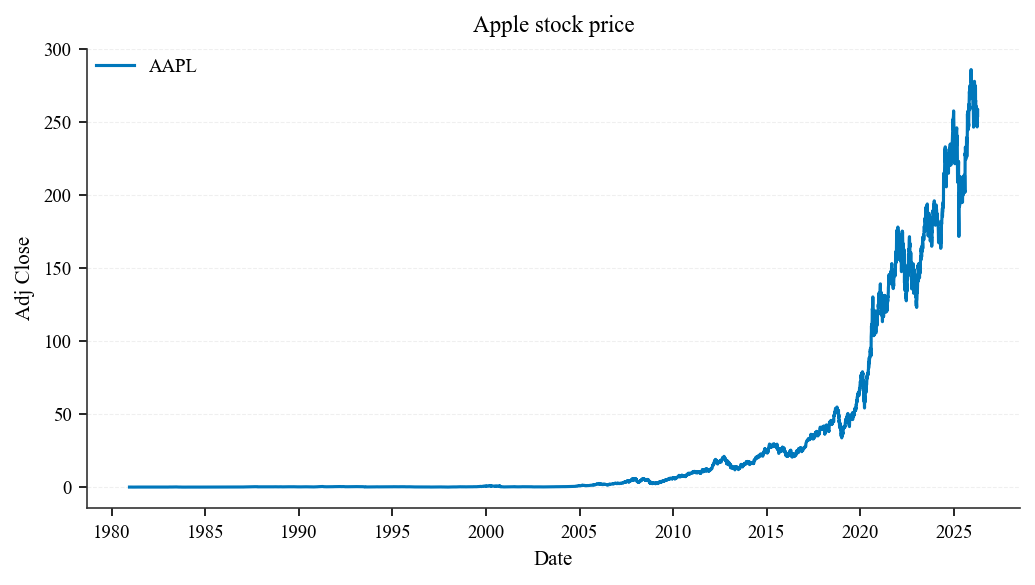

,AAPL
Date,
1980-12-12,0.09829751
1980-12-15,0.09316928
1980-12-16,0.08633082
1980-12-17,0.08846761
1980-12-18,0.09103247
...,...
2026-04-01,255.63000488
2026-04-02,255.91999817
2026-04-06,258.85998535


In [5]:
plots.YahooFinance.show_chart(apple, "AAPL", title="Apple stock price", hide_col=True)

#### Uzyskanie danych o indeksie

Na platformie Yahoo Finance dostępne są różne tickery reprezentujące indeks S&P 500, które różnią się sposobem uwzględniania dywidend:

- **SP500 (^GSPC, S&P 500)** – indeks cenowy (*price return*), uwzględniający wyłącznie zmiany cen akcji spółek wchodzących w skład indeksu
- **SP500TR (^SP500TR, S&P 500 Total Return)** – indeks dochodowy (*total return*), uwzględniający zarówno zmiany cen, jak i reinwestowane dywidendy
- **ETF (CSPX.L, iShares Core S&P 500 UCITS ETF Acc)** – fundusz ETF replikujący indeks S&P 500 w sposób fizyczny, akumulujący dywidendy (reinwestowane wewnątrz funduszu), stanowiący przybliżenie rzeczywistej stopy zwrotu inwestora

Zestawienie tych trzech instrumentów pozwala porównać:
- wpływ dywidend na długoterminową stopę zwrotu,
- różnice między indeksem teoretycznym a rzeczywistym instrumentem inwestycyjnym,
- dokładność odwzorowania indeksu przez ETF (tzw. *tracking error*).

In [6]:
SP500 = dataset.YahooFinance.get_ticker_data_incremental("^GSPC", save_csv=True)
SP500TR = dataset.YahooFinance.get_ticker_data_incremental("^SP500TR", save_csv=True)
ETF = dataset.YahooFinance.get_ticker_data_incremental("CSPX.L", save_csv=True)

plots.summarize_df(SP500)
plots.summarize_df(SP500TR)
plots.summarize_df(ETF)

Loading existing data for ^GSPC from ^GSPC.csv
No new trading days for ^GSPC since 2026-04-08
Saved data for ^GSPC to ^GSPC.csv
Loading existing data for ^SP500TR from ^SP500TR.csv
No new trading days for ^SP500TR since 2026-04-08
Saved data for ^SP500TR to ^SP500TR.csv
Loading existing data for CSPX.L from CSPX.L.csv
Fetching new data for CSPX.L since 2026-04-07
Updated CSPX.L with new data
Saved data for CSPX.L to CSPX.L.csv
DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 24683 entries, 1927-12-30 05:00:00+00:00 to 2026-04-08 04:00:00+00:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          24683 non-null  float64
 1   High          24683 non-null  float64
 2   Low           24683 non-null  float64
 3   Close         24683 non-null  float64
 4   Adj Close     24683 non-null  float64
 5   Volume        24683 non-null  int64  
 6   Dividends     24683 non-null  float64
 7   Stock Splits  

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,24683.00000000,24683.00000000,24683.00000000,24683.00000000,24683.00000000,24683.00000000,24683.00000000,24683.00000000
mean,730.98077828,735.18004374,726.50397806,731.12542909,731.12542909,974293729.24685001,0.00000000,0.00000000
std,1254.40511390,1261.04008631,1247.21355949,1254.59595212,1254.59595212,1691858984.05678535,0.00000000,0.00000000
min,4.40000010,4.40000010,4.40000010,4.40000010,4.40000010,0.00000000,0.00000000,0.00000000
25%,24.95999908,24.95999908,24.95999908,24.95999908,24.95999908,1600000.00000000,0.00000000,0.00000000
50%,103.62000275,104.44999695,102.79000092,103.62000275,103.62000275,22340000.00000000,0.00000000,0.00000000
75%,1093.86499023,1099.64001465,1084.79504395,1093.58001709,1093.58001709,1188000000.00000000,0.00000000,0.00000000
max,7002.00000000,7002.27978516,6963.45996094,6978.60009766,6978.60009766,11456230000.00000000,0.00000000,0.00000000


DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 9638 entries, 1988-01-04 05:00:00+00:00 to 2026-04-08 04:00:00+00:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          9638 non-null   float64
 1   High          9638 non-null   float64
 2   Low           9638 non-null   float64
 3   Close         9638 non-null   float64
 4   Adj Close     9638 non-null   float64
 5   Volume        9638 non-null   int64  
 6   Dividends     9638 non-null   float64
 7   Stock Splits  9638 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 677.7 KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,9638.00000000,9638.00000000,9638.00000000,9638.00000000,9638.00000000,9638.00000000,9638.00000000,9638.00000000
mean,3292.99485323,3306.99199612,3277.96385329,3293.54184955,3293.54184955,0.00000000,0.00000000,0.00000000
std,3429.98162624,3449.39950087,3408.88175779,3430.47652074,3430.47652074,0.00000000,0.00000000,0.00000000
min,242.86999512,242.86999512,242.86999512,242.86999512,242.86999512,0.00000000,0.00000000,0.00000000
25%,1168.84994507,1168.84994507,1168.84994507,1168.84994507,1168.84994507,0.00000000,0.00000000,0.00000000
50%,1917.32000732,1920.03002930,1914.33001709,1917.45001221,1917.45001221,0.00000000,0.00000000,0.00000000
75%,4098.70495605,4112.54003906,4079.31756592,4097.68981934,4097.68981934,0.00000000,0.00000000,0.00000000
max,15580.04003906,15580.58984375,15494.28027344,15527.82031250,15527.82031250,0.00000000,0.00000000,0.00000000


DataFrame summary:
<class 'pandas.DataFrame'>
Index: 3929 entries, 2010-09-14 23:00:00+00:00 to 2026-04-08 00:00:00+01:00
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           3929 non-null   float64
 1   High           3929 non-null   float64
 2   Low            3929 non-null   float64
 3   Close          3929 non-null   float64
 4   Adj Close      3929 non-null   float64
 5   Volume         3929 non-null   int64  
 6   Dividends      3929 non-null   float64
 7   Stock Splits   3929 non-null   float64
 8   Capital Gains  3929 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 307.0+ KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
count,3929.00000000,3929.00000000,3929.00000000,3929.00000000,3929.00000000,3929.00000000,3929.00000000,3929.00000000,3929.00000000
mean,308.75687179,314.86739542,306.99184810,308.78397303,308.78397303,96970.63731229,0.00000000,0.00000000,0.00000000
std,172.67451797,183.47416418,171.61110425,172.70338106,172.70338106,118493.95204558,0.00000000,0.00000000,0.00000000
min,94.23999786,94.50000000,1.00000000,94.58499908,94.58499908,0.00000000,0.00000000,0.00000000,0.00000000
25%,176.53999329,177.38999939,175.30000305,176.35000610,176.35000610,19938.00000000,0.00000000,0.00000000,0.00000000
50%,262.75000000,263.76000977,261.14999390,262.82998657,262.82998657,73718.00000000,0.00000000,0.00000000,0.00000000
75%,428.76000977,430.57000732,426.45999146,428.42001343,428.42001343,128484.00000000,0.00000000,0.00000000,0.00000000
max,751.09002686,888.76000977,746.71417236,748.88000488,748.88000488,1665039.00000000,0.00000000,0.00000000,0.00000000


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,,
2010-09-14 23:00:00+00:00,95.81999969,95.81999969,95.81999969,95.54000092,95.54000092,1,0.00000000,0.00000000,0.00000000
2010-09-15 23:00:00+00:00,95.54000092,95.54000092,95.54000092,95.54000092,95.54000092,0,0.00000000,0.00000000,0.00000000
2026-04-06 23:00:00+00:00,707.52001953,711.98999023,701.97998047,704.40002441,704.40002441,116896,0.00000000,0.00000000,0.00000000
2026-04-08 00:00:00+01:00,728.84002686,731.14001465,724.15997314,726.65997314,726.65997314,199257,0.00000000,0.00000000,0.00000000


Wyniki z kolumny Close i Adj Close są jednakowe.

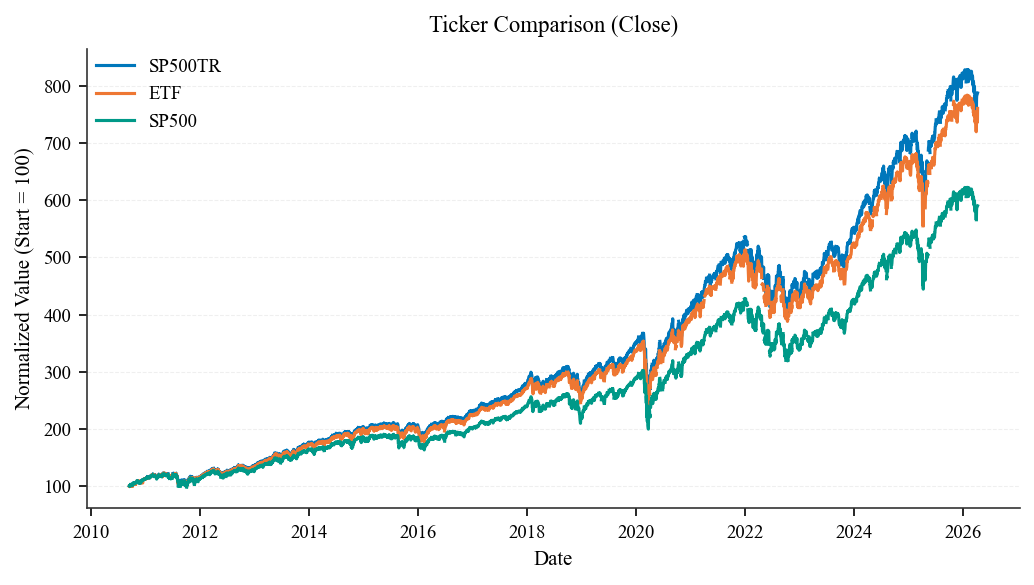

,SP500TR,ETF,SP500
Date,,,
2010-09-14,100.00000000,100.00000000,100.00000000
2010-09-15,100.35591222,100.00000000,100.35411389
2010-09-16,100.33616935,100.00000000,100.31755050
2010-09-17,100.41941377,NaN,100.40049865
2010-09-19,NaN,100.00000000,NaN
...,...,...,...
2026-03-31,776.95872712,741.31253215,582.33165299
2026-04-01,782.55775440,738.86326814,586.50610716
2026-04-02,783.49264521,NaN,587.16350769


In [7]:
plots.YahooFinance.compare_tickers({
    "SP500": SP500,
    "SP500TR": SP500TR,
    "ETF": ETF
}, col="Close")

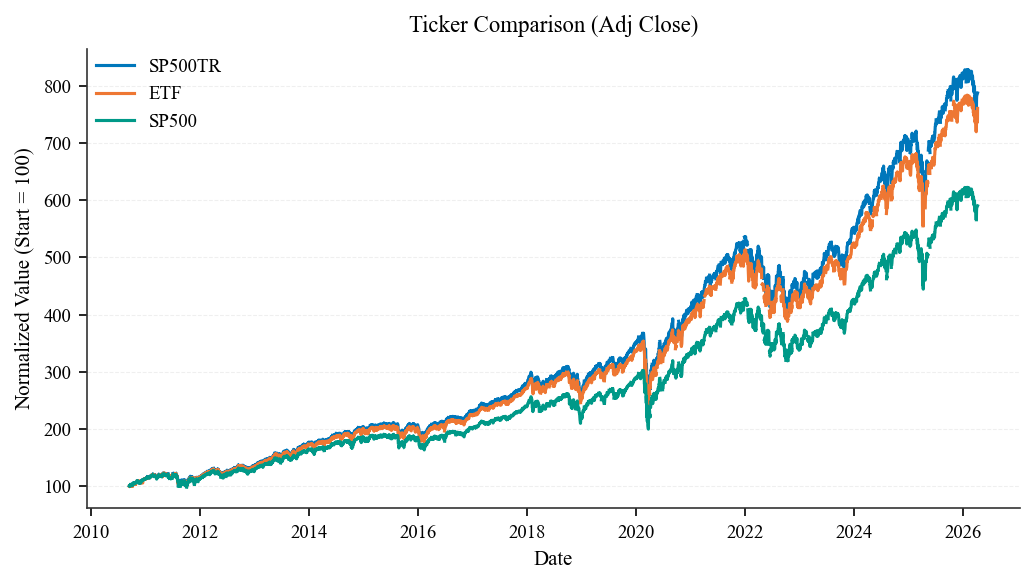

,SP500TR,ETF,SP500
Date,,,
2010-09-14,100.00000000,100.00000000,100.00000000
2010-09-15,100.35591222,100.00000000,100.35411389
2010-09-16,100.33616935,100.00000000,100.31755050
2010-09-17,100.41941377,NaN,100.40049865
2010-09-19,NaN,100.00000000,NaN
...,...,...,...
2026-03-31,776.95872712,741.31253215,582.33165299
2026-04-01,782.55775440,738.86326814,586.50610716
2026-04-02,783.49264521,NaN,587.16350769


In [8]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "SP500": SP500,
    "ETF": ETF
}, col="Adj Close")

Widzimy nie tylko różnicę między indeksem uwzględniającym dywidendy a tym nieuwzględniającym, ale także między indeksem total return a odpowiadającym mu ETF-em, który zwykle osiąga nieco niższe wyniki z powodu **błędu odwzorowania** (tracking error). Sam ETF nie jest więc wystarczający jako pełny benchmark historyczny, ponieważ jego najdłuższa porównywalna historia (dla ETF-u akumulującego dywidendy) rozpoczyna się dopiero około 2010 roku. Z tego powodu w analizie potrzebne są oba szeregi: **SP500TR** (długi horyzont historyczny i referencja total return) oraz **benchmark hybrydowy** (odwzorowanie realnych warunków inwestora poprzez uwzględnienie tracking error i wykorzystanie rzeczywistych notowań ETF tam, gdzie są dostępne).

#### Hybrydowy indeks S&P 500

W praktyce: SP500TR odpowiada za część historyczną (przed debiutem ETF), a hybryda zapewnia ciągłość serii i porównywalność wyników z realnym instrumentem inwestycyjnym.

Do konstrukcji hybrydowego indeksu rozważono podejścia oparte na **splicingu**, tj. łączeniu fragmentów szeregów czasowych w jedną spójną serię. Przyjęto, że w okresie dostępności ETF-u indeks hybrydowy odpowiada jego rzeczywistym notowaniom, natomiast wcześniejsze obserwacje są rekonstruowane na podstawie indeksu SP500TR.

Rozważono następujące podejścia:

1. **Proste skalowanie** — dane SP500TR są skalowane tak, aby ich wartość w punkcie łączenia była zgodna z wartością ETF-u.

2. **Bezwzględna różnica odwzorowania (tracking difference)** — w okresie wspólnym estymowana jest średnia różnica stóp zwrotu:

   $$\overline{\text{TD}} = \frac{1}{T}\sum_{t=1}^{T}(R_{\text{TR}} - R_{\text{ETF}}),$$

   która następnie koryguje historyczne stopy zwrotu:

   $$r_{\text{HYB}} = R_{\text{TR}} - \overline{\text{TD}}.$$

   Podejście to pomija jednak kumulatywny charakter błędu odwzorowania oraz jego proporcjonalność do poziomu cen.

3. **Względna różnica odwzorowania** — w okresie wspólnym estymowana jest relatywna różnica wyników ETF względem indeksu:

   $$
   TD_{annual} = \left(\frac{R_{\text{TR}}}{R_{\text{ETF}}}\right)^{\frac{252}{N}} - 1,
   $$

   gdzie $R_{\text{TR}}$ i $R_{\text{ETF}}$ oznaczają całkowite stopy zwrotu, a $N$ liczbę dni sesyjnych.

   Otrzymany parametr interpretowany jest jako średni roczny koszt odwzorowania i przekształcany do dziennego czynnika, który jest następnie kumulowany wstecznie:

   $$
   P^{adj}_t = \frac{P_t}{d^k}, \quad d = (1 + TD_{annual})^{1/252},
   $$

   gdzie $k$ oznacza liczbę dni od momentu rozpoczęcia notowań ETF.

   Tak skorygowana seria jest następnie skalowana w punkcie łączenia w celu zapewnienia ciągłości z rzeczywistymi notowaniami ETF.

Do utworzenia benchmarku przyjęto **trzecie podejście**, ponieważ pozwala ono uchwycić kumulatywny charakter błędu odwzorowania, przy jednoczesnym zachowaniu prostoty i stabilności estymacji oraz pełnej zgodności z obserwowanymi danymi ETF po dacie jego debiutu.

Loading existing benchmark from /home/michael/Documents/University/Semestr 4/Projekt indywidualny/Repo/data/processed/benchmark_2026-04-08.csv
DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 24683 entries, 1927-12-30 05:00:00+00:00 to 2026-04-08 04:00:00+00:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          24683 non-null  float64
 1   High          24683 non-null  float64
 2   Low           24683 non-null  float64
 3   Close         24683 non-null  float64
 4   Adj Close     24683 non-null  float64
 5   Volume        24683 non-null  int64  
 6   Dividends     24683 non-null  float64
 7   Stock Splits  24683 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 1.7 MB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,24683.00000000,24683.00000000,24683.00000000,24683.00000000,24683.00000000,24683.00000000,24683.00000000,24683.00000000
mean,730.98077828,735.18004374,726.50397806,731.12542909,731.12542909,974293729.24685001,0.00000000,0.00000000
std,1254.40511390,1261.04008631,1247.21355949,1254.59595212,1254.59595212,1691858984.05678535,0.00000000,0.00000000
min,4.40000010,4.40000010,4.40000010,4.40000010,4.40000010,0.00000000,0.00000000,0.00000000
25%,24.95999908,24.95999908,24.95999908,24.95999908,24.95999908,1600000.00000000,0.00000000,0.00000000
50%,103.62000275,104.44999695,102.79000092,103.62000275,103.62000275,22340000.00000000,0.00000000,0.00000000
75%,1093.86499023,1099.64001465,1084.79504395,1093.58001709,1093.58001709,1188000000.00000000,0.00000000,0.00000000
max,7002.00000000,7002.27978516,6963.45996094,6978.60009766,6978.60009766,11456230000.00000000,0.00000000,0.00000000


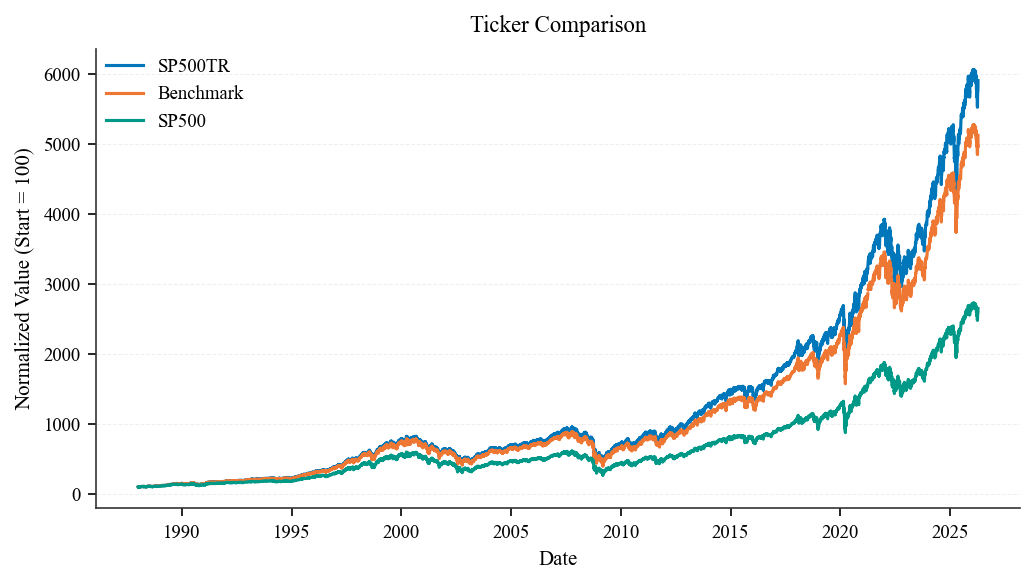

,SP500TR,Benchmark,SP500
Date,,,
1988-01-04,100.00000000,100.00000000,100.00000000
1988-01-05,101.07413488,101.07266905,101.05102853
1988-01-06,101.17569326,101.17275868,101.15261865
1988-01-07,102.02718642,102.02274753,102.00437791
1988-01-08,95.12929205,95.12377371,95.10041087
...,...,...,...
2026-04-01,5728.33384768,4994.21782127,2569.08641146
2026-04-02,5735.17726170,4977.71714520,2571.96603837
2026-04-06,5760.99922007,NaN,2583.35157266


In [9]:
benchmark = features.construct_hybrid(
    long_df=SP500TR,
    short_df=ETF,
    save_csv=True,
    cleanup_old=True
)

plots.summarize_df(SP500)

plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    # "ETF": ETF, # here shows only after 2010-09-14
    "SP500": SP500
}, hide_col=True)

Poniżej przedstawiono wizualizację dwóch okresów hybrydowego indeksu:  
- **przed debiutem ETF** – historyczne notowania odtworzone na podstawie SP500TR z uwzględnieniem tracking difference.  
- **po debiucie ETF** – hybrydowy indeks pokrywa się z ETF-em.

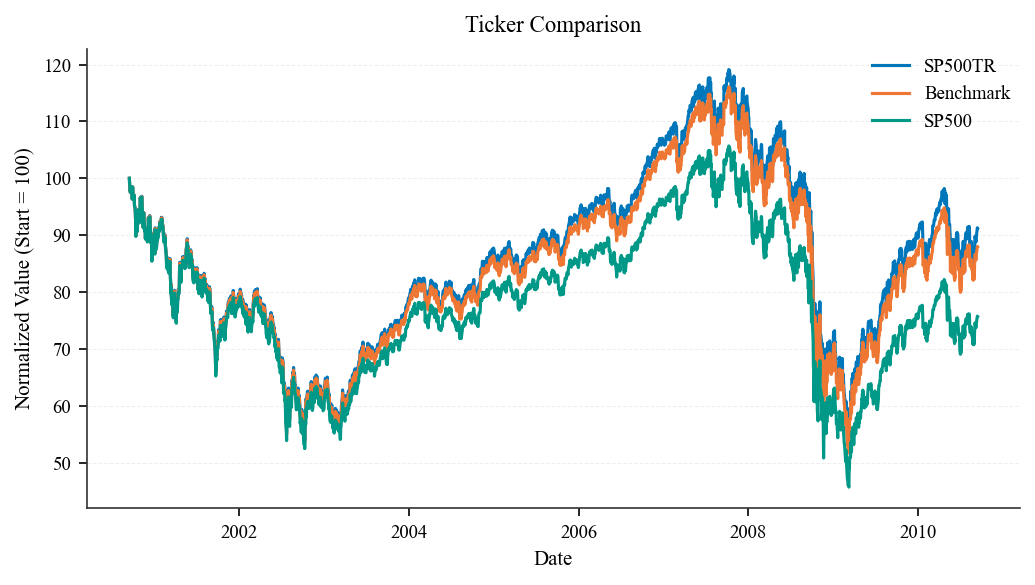

,SP500TR,Benchmark,SP500
Date,,,
2000-09-14,100.00000000,100.00000000,100.00000000
2000-09-15,98.98306332,98.98162781,98.98303453
2000-09-18,97.54650677,97.54367745,97.54468755
2000-09-19,98.58632187,98.58203268,98.58394250
2000-09-20,98.01042757,98.00474210,98.00589995
...,...,...,...
2010-09-08,89.38764760,86.19355731,74.20435276
2010-09-09,89.81993082,86.60913767,74.56292972
2010-09-10,90.25854274,87.03080835,74.92555407


In [10]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    "SP500": SP500
}, hide_col=True, start_date="2000-09-14", end_date="2010-09-14")

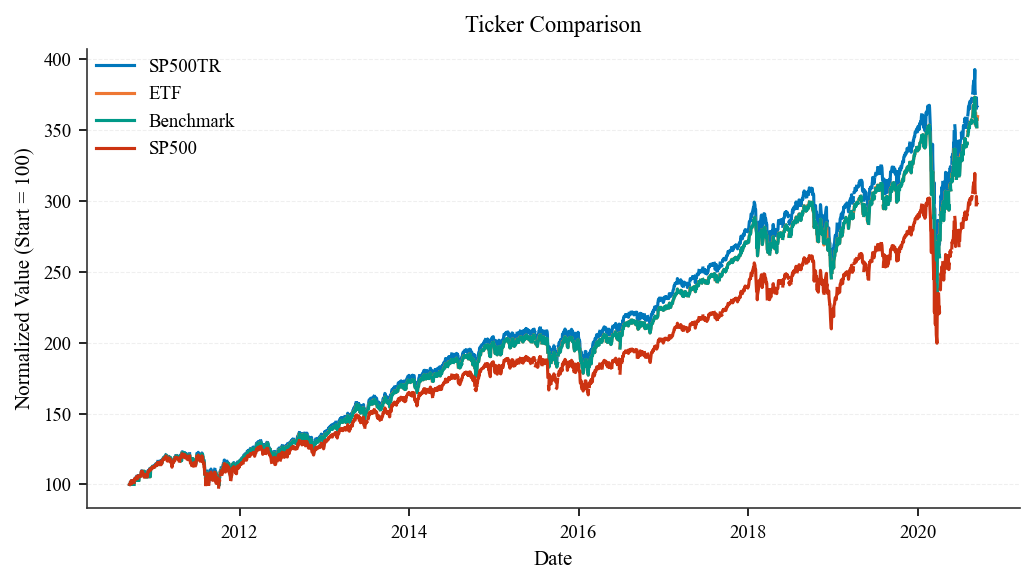

,SP500TR,ETF,Benchmark,SP500
Date,,,,
2010-09-14,100.00000000,100.00000000,100.00000000,100.00000000
2010-09-15,100.35591222,100.00000000,100.00000000,100.35411389
2010-09-16,100.33616935,100.00000000,100.00000000,100.31755050
2010-09-17,100.41941377,NaN,100.00000000,100.40049865
2010-09-19,NaN,100.00000000,NaN,NaN
...,...,...,...,...
2020-09-09,372.81211299,357.89197132,357.72449837,303.18080768
2020-09-10,366.27394800,352.26081701,357.89197132,297.84943485
2020-09-11,366.48686611,NaN,352.26081701,298.00821010


In [11]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    "ETF": ETF,
    "SP500": SP500
}, hide_col=True, start_date="2010-09-14", end_date="2020-09-14")

#### S&P 500 Equal Weighted

Dla indeksu S&P 500 Equal Weighted dostępne są następujące tickery:

- **SP500EW (^SP500EW, S&P 500 Equal Weight Index)** – indeks cenowy (*price return*) równoważonej wersji S&P 500, gdzie każda spółka ma identyczny udział niezależnie od kapitalizacji
- **ETF_EW (RSP, Invesco S&P 500 Equal Weight ETF)** – fundusz ETF replikujący indeks S&P 500 z równymi wagami, akumulujący dywidendy

Na wykresie widać, że w ostatnich latach benchmark oparty na S&P 500 przewyższał ETF na S&P 500 Equal Weight. Jednak w latach przed 2018 strategia równych wag często osiągała podobne lub lepsze wyniki. Oznacza to, że relatywna efektywność podejścia equal-weight w dużej mierze zależy od siły największych spółek w indeksie.

Loading existing data for ^SP500EW from ^SP500EW.csv
No new trading days for ^SP500EW since 2026-04-08
Saved data for ^SP500EW to ^SP500EW.csv
Loading existing data for RSP from RSP.csv
No new trading days for RSP since 2026-04-08
Saved data for RSP to RSP.csv
DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 4847 entries, 2006-12-08 05:00:00+00:00 to 2026-04-08 04:00:00+00:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          4847 non-null   float64
 1   High          4847 non-null   float64
 2   Low           4847 non-null   float64
 3   Close         4847 non-null   float64
 4   Adj Close     4847 non-null   float64
 5   Volume        4847 non-null   int64  
 6   Dividends     4847 non-null   float64
 7   Stock Splits  4847 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 340.8 KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,4847.00000000,4847.00000000,4847.00000000,4847.00000000,4847.00000000,4847.00000000,4847.00000000,4847.00000000
mean,3800.13658162,3823.96141398,3775.71676507,3801.39974926,3801.39974926,0.78399010,0.00000000,0.00000000
std,1917.87557105,1928.30483174,1908.22193561,1918.66280277,1918.66280277,54.58170361,0.00000000,0.00000000
min,824.01000977,849.15997314,810.59997559,824.01000977,824.01000977,0.00000000,0.00000000,0.00000000
25%,2025.82495117,2035.97998047,2013.38500977,2026.00000000,2026.00000000,0.00000000,0.00000000,0.00000000
50%,3342.70996094,3353.97998047,3326.07006836,3342.87011719,3342.87011719,0.00000000,0.00000000,0.00000000
75%,5596.53491211,5659.94995117,5550.66992188,5601.71997070,5601.71997070,0.00000000,0.00000000,0.00000000
max,8289.28027344,8306.87988281,8219.33984375,8290.63964844,8290.63964844,3800.00000000,0.00000000,0.00000000


DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 5771 entries, 2003-05-01 04:00:00+00:00 to 2026-04-08 04:00:00+00:00
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           5771 non-null   float64
 1   High           5771 non-null   float64
 2   Low            5771 non-null   float64
 3   Close          5771 non-null   float64
 4   Adj Close      5771 non-null   float64
 5   Volume         5771 non-null   int64  
 6   Dividends      5771 non-null   float64
 7   Stock Splits   5771 non-null   float64
 8   Capital Gains  5771 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 450.9 KB
None


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
count,5771.00000000,5771.00000000,5771.00000000,5771.00000000,5771.00000000,5771.00000000,5771.00000000,5771.00000000,5771.00000000
mean,84.99787776,85.46473052,84.47067671,84.99939311,74.71956359,2077877.35678392,0.00541067,0.00069312,0.00000000
std,47.97397651,48.21273508,47.72968621,47.97863500,49.50787196,3720608.96879607,0.05082325,0.05265437,0.00000000
min,20.59000015,21.15999985,18.00000000,20.59000015,15.51314831,4400.00000000,0.00000000,0.00000000,0.00000000
25%,43.79500008,44.06999969,43.47999954,43.75624847,32.69106674,397900.00000000,0.00000000,0.00000000,0.00000000
50%,75.55999756,75.98000336,75.15000153,75.62000275,62.41214371,780600.00000000,0.00000000,0.00000000,0.00000000
75%,111.90500259,112.40500259,111.34500122,111.84999847,100.99169159,1982700.00000000,0.00000000,0.00000000,0.00000000
max,204.27000427,205.24000549,203.17999268,204.97000122,204.09623718,57508500.00000000,0.83100000,4.00000000,0.00000000


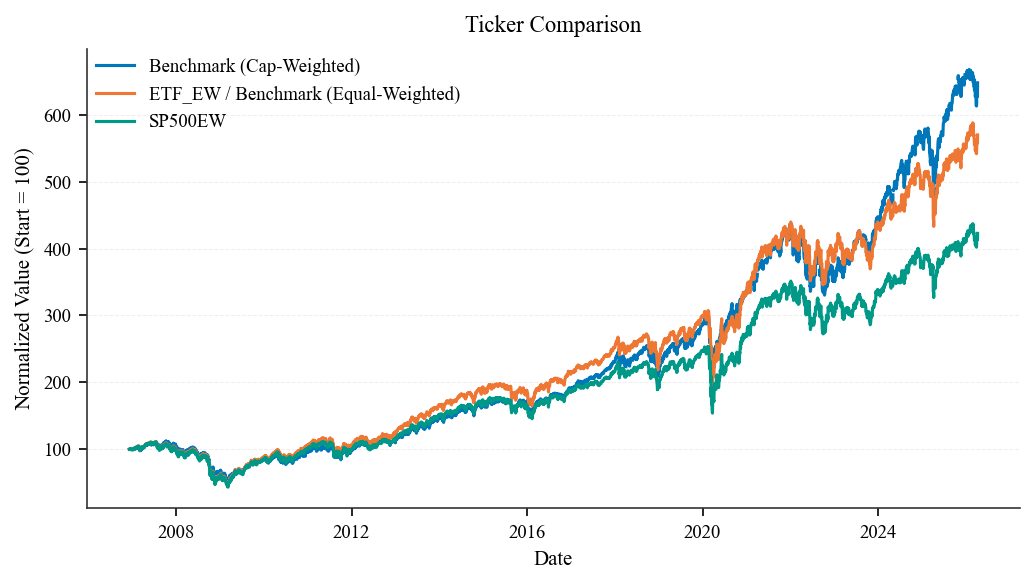

,Benchmark (Cap-Weighted),ETF_EW / Benchmark (Equal-Weighted),SP500EW
Date,,,
2006-12-08,100.00000000,100.00000000,100.00000000
2006-12-11,100.22702761,100.04197496,100.08383243
2006-12-12,100.12331382,99.89499667,99.87873422
2006-12-13,100.25728463,100.06296244,99.92091110
2006-12-14,101.13424460,100.79776597,100.74660099
...,...,...,...
2026-04-01,631.24944928,554.61012515,411.42412341
2026-04-02,629.16382886,556.19440516,412.66951609
2026-04-06,NaN,558.58521972,414.42319395


In [12]:
SP500EW = dataset.YahooFinance.get_ticker_data_incremental("^SP500EW", save_csv=True)
ETF_EW = dataset.YahooFinance.get_ticker_data_incremental("RSP", save_csv=True)

plots.summarize_df(SP500EW)
plots.summarize_df(ETF_EW)

plots.YahooFinance.compare_tickers({
    "Benchmark (Cap-Weighted)": benchmark,
    "ETF_EW / Benchmark (Equal-Weighted)": ETF_EW,
    "SP500EW": SP500EW,
}, hide_col=True)

Analogicznie do hybrydowego benchmarku dla S&P 500 ważonego kapitalizacją, można byłoby
skonstruować benchmark hybrydowy dla wersji equal-weighted, uwzględniając wpływ dywidend
zamiast błędu odwzorowania. W tym przypadku jednak `ETF_EW` (RSP) dysponuje najdłuższą
dostępną historią — sięgającą 2003 roku — a przedłużenie jej wstecz napotyka na istotne
ograniczenia: indeks dochodowy `SP500EWTR` nie jest dostępny w serwisie Yahoo Finance,
`SP500EW` obejmuje krótszy okres, natomiast zastosowanie benchmarku cap-weighted jako
substytutu zniekształciłoby charakterystykę strategii equal-weighted. Z tego powodu
`benchmark_ew` ograniczony jest do okresu dostępności `ETF_EW`, a porównanie obu podejść
prowadzone jest na wspólnym horyzoncie czasowym.

In [13]:
benchmark_ew = SP500EW

#### Uzyskanie danych pojedyńczych spółek

In [14]:
tickers = dataset.tickers_from_sp500_components(sp500_components)

yf_data: dict[str, pd.DataFrame] = dataset.YahooFinance.download(tickers, save_csv=True)
for column_name, frame in yf_data.items():
    if frame.empty:
        print(f"{column_name}: empty")
    else:
        print(f"{column_name}: {frame.shape}, {frame.index.min().date()} -> {frame.index.max().date()}")

Number of unique tickers extracted: 1194
No new trading days since 2026-04-08.
Skipping missing ticker re-download (redownload_missing_tickers=False)
Close: (16174, 1194), 1962-01-02 -> 2026-04-08
Open: (16174, 1194), 1962-01-02 -> 2026-04-08
High: (16174, 1194), 1962-01-02 -> 2026-04-08
Low: (16174, 1194), 1962-01-02 -> 2026-04-08
Volume: (16174, 1194), 1962-01-02 -> 2026-04-08
Adj_Close: (16174, 1194), 1962-01-02 -> 2026-04-08


#### Ile danych brakuje?

Na poniższym wykresie widać, że w 1996 dane z Yahoo Finance pokrywają tylko 38%. Przy wyższym pokryciu można byłoby zastosować imputację brakujących danych, jednak jest ono na tyle małe, że konieczne będzie skorzystanie z dostawców danych, pokrywających spółki, które już nie są notowane.

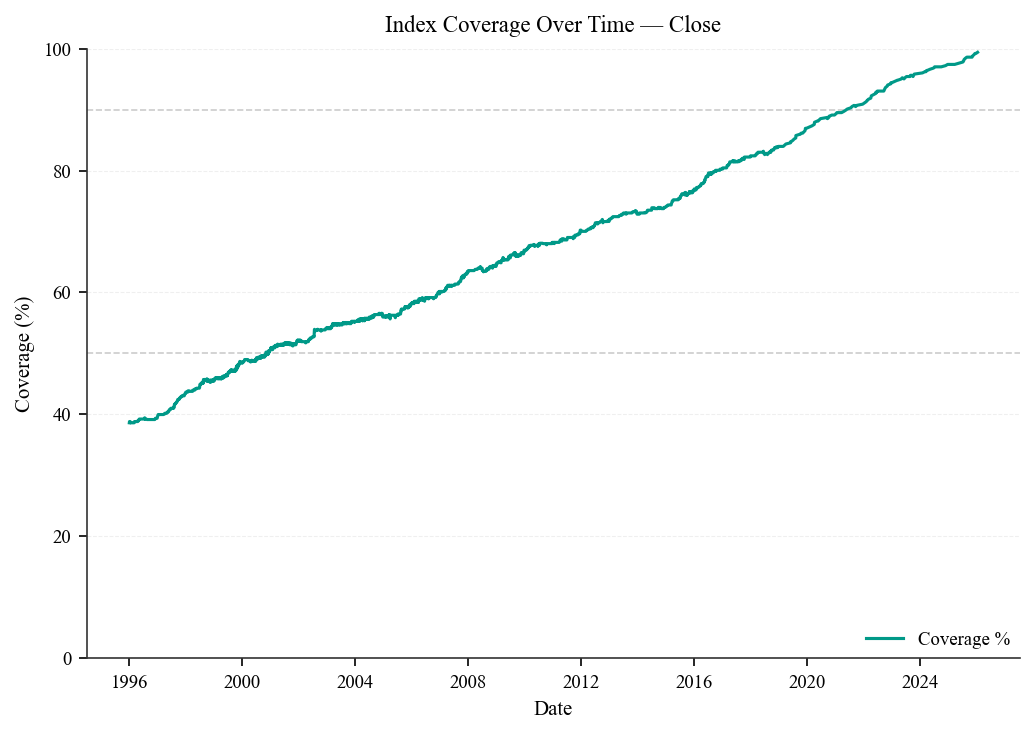

DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 2705 entries, 1996-01-02 to 2026-01-14
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   available       2705 non-null   int64  
 1   missing         2705 non-null   int64  
 2   not_downloaded  2705 non-null   int64  
 3   total           2705 non-null   int64  
 4   coverage_pct    2705 non-null   float64
dtypes: float64(1), int64(4)
memory usage: 126.8 KB
None


,available,missing,not_downloaded,total,coverage_pct
count,2705.00000000,2705.00000000,2705.00000000,2705.00000000,2705.00000000
mean,312.33456562,184.41478743,0.00000000,496.74935305,62.74024896
std,72.67110043,67.86120377,0.00000000,5.16624733,14.01065160
min,188.00000000,3.00000000,0.00000000,487.00000000,38.60369610
25%,255.00000000,133.00000000,0.00000000,494.00000000,51.51515152
50%,313.00000000,184.00000000,0.00000000,497.00000000,62.97786720
75%,364.00000000,240.00000000,0.00000000,499.00000000,73.23943662
max,500.00000000,299.00000000,0.00000000,507.00000000,99.40357853


,available,missing,not_downloaded,total,coverage_pct
1996-01-02,188,299,0,487,38.60369610
1996-01-03,189,298,0,487,38.80903491
2025-12-22,499,4,0,503,99.20477137
2026-01-14,500,3,0,503,99.40357853


In [15]:
coverage_df = plots.coverage_over_time(yf_data, sp500_components)
plots.summarize_df(coverage_df)

### Dane cenowe z EODHD

Na EODHD dostępnych jest kilka tickerów, dla których można korzystać z danych bezpłatnie. W przypadku akcji amerykańskich są to:
- AAPL.US
- TSLA.US
- VTI.US
- AMZN.US

In [17]:
api_key = "demo"
free_tickers = ["AAPL.US", "TSLA.US", "VTI.US", "AMZN.US"]

eodhd_data_free_tickers: dict[str, pd.DataFrame] = dataset.EODHD.download(
    tickers=free_tickers,
    api_key=api_key,
    save_csv=True
)

for column_name, frame in eodhd_data_free_tickers.items():
    if frame.empty:
        print(f"{column_name}: empty")
    else:
        print(f"{column_name}: {frame.shape}, {frame.index.name or 'Date'}: {frame.index.min().date()} -> {frame.index.max().date()}")

Number of unique tickers extracted: 4
No new trading days since 2026-04-07.
Skipping missing ticker re-download (redownload_missing_tickers=False)
EODHD per-ticker status:
  AAPL.US.US: skipped_not_in_existing_dataset
  AMZN.US.US: skipped_not_in_existing_dataset
  TSLA.US.US: skipped_not_in_existing_dataset
  VTI.US.US: skipped_not_in_existing_dataset
Close: (11420, 4), Date: 1980-12-12 -> 2026-04-07
Open: (11420, 4), Date: 1980-12-12 -> 2026-04-07
High: (11420, 4), Date: 1980-12-12 -> 2026-04-07
Low: (11420, 4), Date: 1980-12-12 -> 2026-04-07
Volume: (11420, 4), Date: 1980-12-12 -> 2026-04-07
Adj_Close: (11420, 4), Date: 1980-12-12 -> 2026-04-07


In [ ]:
eodhd_data: dict[str, pd.DataFrame] = dataset.EODHD.download(
    tickers,
    save_csv=True,
    redownload_missing_tickers=True,
)

Number of unique tickers extracted: 1194
No new trading days since 2026-04-07.
Checking for missing ticker data...
Found 1192 tickers with >50% missing data. Attempting to re-download...
  A.US: 100.0% NaN
  AABA.US: 100.0% NaN
  AAL.US: 100.0% NaN
  AAMRQ.US: 100.0% NaN
  AAP.US: 100.0% NaN
  ABBV.US: 100.0% NaN
  ABC.US: 100.0% NaN
  ABI.US: 100.0% NaN
  ABKFQ.US: 100.0% NaN
  ABMD.US: 100.0% NaN
  ... and 1182 more
No valid data returned for AAMRQ.US
No valid data returned for ABKFQ.US


[20:36:16] Expecting value: line 1 column 1 (char 0)                                                  BaseAPI.py:39

           404 Client Error: Not Found for url:                                                       BaseAPI.py:52
           https://eodhd.com/api/eod/AFS.A.US?api_token=69b00122c69c14.83606105&fmt=json&period=d&ord              
           er=a                                                                                                    

No valid data returned for AFS.A.US


[20:38:58] Expecting value: line 1 column 1 (char 0)                                                  BaseAPI.py:39

...

           404 Client Error: Not Found for url:                                                       BaseAPI.py:52
           https://eodhd.com/api/eod/USH.US?api_token=69b00122c69c14.83606105&fmt=json&period=d&order              
           =a                                                                                                      

No valid data returned for USH.US


[21:20:15] Expecting value: line 1 column 1 (char 0)                                                  BaseAPI.py:39

           404 Client Error: Not Found for url:                                                       BaseAPI.py:52
           https://eodhd.com/api/eod/USHC.US?api_token=69b00122c69c14.83606105&fmt=json&period=d&orde              
           r=a                                                                                                     

No valid data returned for USHC.US
No valid data returned for VAT.US
No valid data returned for WCOEQ.US
Successfully re-downloaded and merged data for 1192 tickers
EODHD per-ticker status:
  A.US: downloaded
  AABA.US: downloaded
  AAL.US: downloaded
  AAMRQ.US: no_valid_data
  AAP.US: downloaded
  ABBV.US: downloaded
  ABC.US: downloaded
  ABI.US: downloaded
  ABKFQ.US: no_valid_data
  ABMD.US: downloaded
  ABNB.US: downloaded
  ABS.US: downloaded
  ABT.US: downloaded
  ABX.US: downloaded
  ACAS.US: downloaded
  ACGL.US: downloaded
  ACKH.US: downloaded
  ACN.US: downloaded
  ACS.US: downloaded
  ACV.US: downloaded
  ADBE.US: downloaded
  ADCT.US: downloaded
  ADI.US: downloaded
  ADM.US: downloaded
  ADP.US: downloaded
  ADS.US: downloaded
  ADSK.US: downloaded
  ADT.US: downloaded
  AEE.US: downloaded
  AEP.US: downloaded
  AES.US: downloaded
  AET.US: downloaded
  AFL.US: downloaded
  AFS.A.US: no_valid_data
  AGC.US: downloaded
  AGN.US: downloaded
  AHM.US: downloaded
  AIG.US: 

In [19]:
for column_name, frame in eodhd_data.items():
    if frame.empty:
        print(f"{column_name}: empty")
    else:
        print(f"{column_name}: {frame.shape}, {frame.index.min().date()} -> {frame.index.max().date()}")

Close: (16203, 1152), 1962-01-02 -> 2026-04-07
Open: (16203, 1152), 1962-01-02 -> 2026-04-07
High: (16203, 1152), 1962-01-02 -> 2026-04-07
Low: (16203, 1152), 1962-01-02 -> 2026-04-07
Volume: (16203, 1152), 1962-01-02 -> 2026-04-07
Adj_Close: (16203, 1152), 1962-01-02 -> 2026-04-07


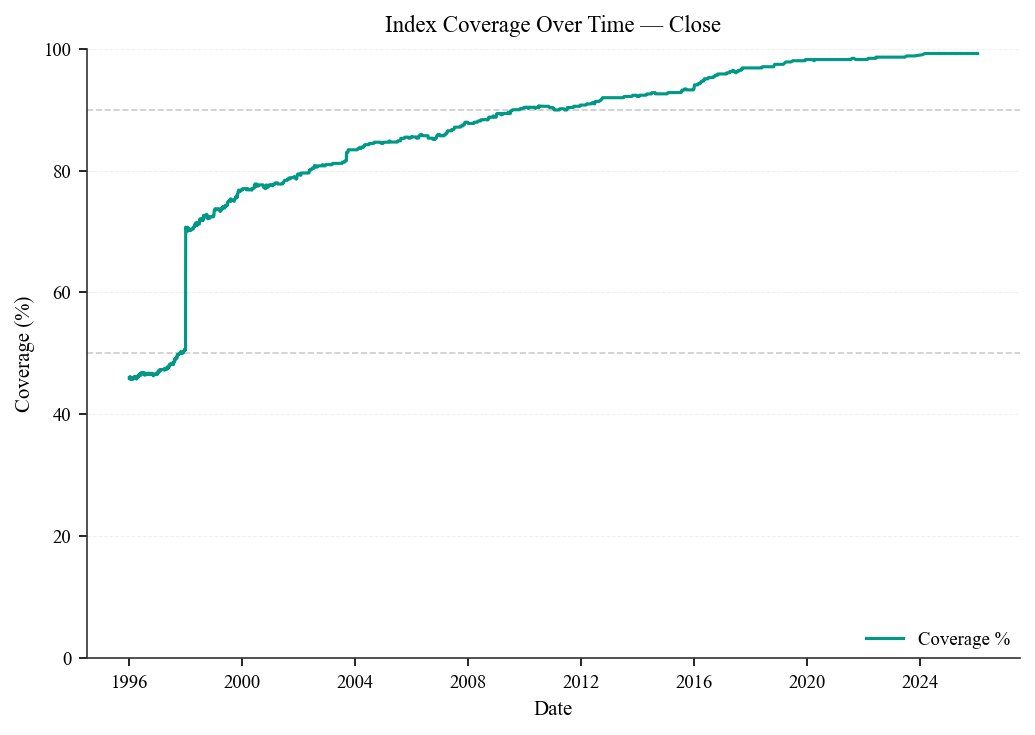

DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 2705 entries, 1996-01-02 to 2026-01-14
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   available       2705 non-null   int64  
 1   missing         2705 non-null   int64  
 2   not_downloaded  2705 non-null   int64  
 3   total           2705 non-null   int64  
 4   coverage_pct    2705 non-null   float64
dtypes: float64(1), int64(4)
memory usage: 126.8 KB
None


,available,missing,not_downloaded,total,coverage_pct
count,2705.00000000,2705.00000000,2705.00000000,2705.00000000,2705.00000000
mean,417.05841035,72.18743068,7.50351201,496.74935305,83.83957722
std,68.38044238,57.14832634,7.14298743,5.16624733,13.12633971
min,223.00000000,2.00000000,2.00000000,487.00000000,45.79055441
25%,389.00000000,36.00000000,3.00000000,494.00000000,78.58585859
50%,436.00000000,56.00000000,5.00000000,497.00000000,87.72635815
75%,459.00000000,95.00000000,11.00000000,499.00000000,92.35412475
max,500.00000000,234.00000000,31.00000000,507.00000000,99.20634921


,available,missing,not_downloaded,total,coverage_pct
1996-01-02,224,233,30,487,45.99589322
1996-01-03,224,233,30,487,45.99589322
2025-12-22,499,2,2,503,99.20477137
2026-01-14,499,2,2,503,99.20477137


In [20]:
coverage_df = plots.coverage_over_time(eodhd_data, sp500_components)
plots.summarize_df(coverage_df)

In [21]:
from pathlib import Path

output_dir = dataset.EODHD.dst_dir
output_dir.mkdir(parents=True, exist_ok=True)

for column_name, frame in eodhd_data.items():
    frame.to_csv(output_dir / f"{column_name}.csv")
    print(f"Saved {column_name}.csv ({len(frame)} rows x {len(frame.columns)} columns)")

Saved Close.csv (16203 rows x 1152 columns)
Saved Open.csv (16203 rows x 1152 columns)
Saved High.csv (16203 rows x 1152 columns)
Saved Low.csv (16203 rows x 1152 columns)
Saved Volume.csv (16203 rows x 1152 columns)
Saved Adj_Close.csv (16203 rows x 1152 columns)
